# Electromotive Force (EMF) Plots

## Data Import

In [2]:
# Read EMF.csv

import pandas as pd
import os.path as path
import matplotlib.pyplot as plt

import darkdetect

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update({
	'figure.dpi': 300,
	'figure.figsize': (8, 5),
})

%config InlineBackend.figure_formats = ['svg']

from matplotlib import cycler

default_cycler = plt.rcParams['axes.prop_cycle']
colors = default_cycler.by_key()['color']
line_styles = ['-', '--', '-.', ':']
combined_cycler = cycler(linestyle=line_styles) * cycler(color=colors)

plt.rcParams['axes.prop_cycle'] = combined_cycler

In [3]:
EMF_DATA_DIR = "../Data/Hand Notes"

emf_df = pd.read_csv(
    path.join(EMF_DATA_DIR, "EMF.csv"),
    delimiter=";",
    index_col=0,
)
emf_df.index = emf_df.index.str.split(
    " ",
    expand=True,
)

In [4]:
# Filter by the second level of the index
emf_vd_df = emf_df.xs("VD", level=1, axis=0)
emf_lt_df = emf_df.xs("LT", level=1, axis=0)

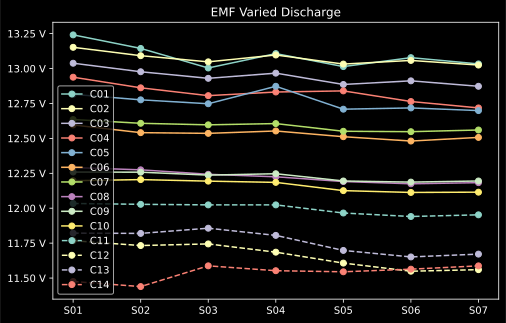

In [10]:
vd_plot = emf_vd_df.plot(
    title="EMF Varied Discharge",
    marker="o",
)
vd_plot.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f} V"))

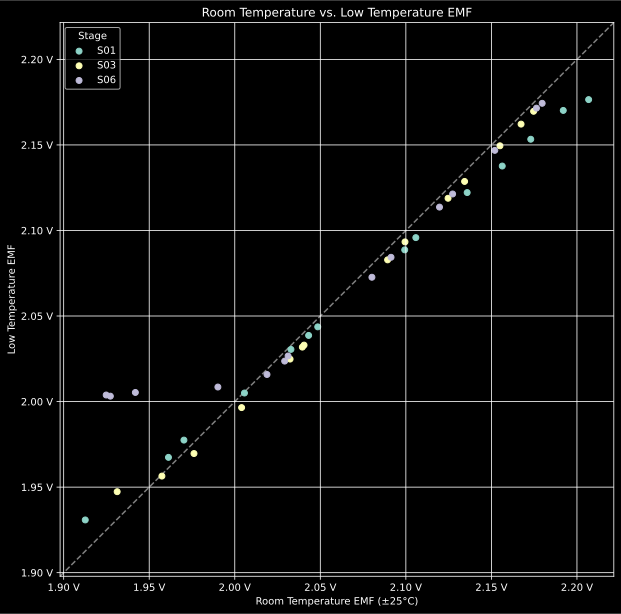

In [9]:
# For each LT stage, plot the corresponding VD EMF for the same stage against the LT EMF
fig, ax = plt.subplots(
    figsize=(10, 10),
)
for stage in emf_lt_df.index.get_level_values(0).unique():
    lt_emf = emf_lt_df.loc[stage]
    vd_emf = emf_vd_df.loc[stage]
    ax.scatter(
        vd_emf / 6,
        lt_emf / 6,
        label=stage,
    )
ax.set_title("Room Temperature vs. Low Temperature EMF")
ax.set_xlabel("Room Temperature EMF (±25°C)")
ax.set_ylabel("Low Temperature EMF")
ax.legend(title="Stage")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f} V"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f} V"))
ax.set_aspect("equal", adjustable="box")
ax.grid()

# Set matching x and y ticks
xlim = ax.get_xlim()
ylim = ax.get_ylim()
min_tick = min(xlim[0], ylim[0])
max_tick = max(xlim[1], ylim[1])
ticks = plt.MaxNLocator(nbins=8).tick_values(min_tick, max_tick)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xlim(min_tick, max_tick)
ax.set_ylim(min_tick, max_tick)

# Plot y=x reference line
ax.plot(
    [min_tick, max_tick], [min_tick, max_tick], color="gray", linestyle="--", zorder=0
)